In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("cancer.csv")
df.head()

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,0,5,1,1,1,2,1,3,1,1
1,0,5,4,4,5,7,10,3,2,1
2,0,3,1,1,1,2,2,3,1,1
3,0,6,8,8,1,3,4,3,7,1
4,0,4,1,1,3,2,1,3,1,1


In [4]:
df.shape

(683, 10)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449 entries, 0 to 682
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Class        449 non-null    int64
 1   age          449 non-null    int64
 2   menopause    449 non-null    int64
 3   tumor-size   449 non-null    int64
 4   inv-nodes    449 non-null    int64
 5   node-caps    449 non-null    int64
 6   deg-malig    449 non-null    int64
 7   breast       449 non-null    int64
 8   breast-quad  449 non-null    int64
 9   irradiat     449 non-null    int64
dtypes: int64(10)
memory usage: 38.6 KB


In [18]:
df.describe()

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,0.525612,5.378619,4.222717,4.273942,3.746102,3.879733,4.806236,4.200445,3.828508,1.913140
std,0.499901,2.869029,3.251280,3.141494,3.158413,2.456544,3.880509,2.651634,3.387146,2.068909
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,1.000000,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000
75%,1.000000,8.000000,7.000000,7.000000,6.000000,5.000000,10.000000,7.000000,7.000000,2.000000
max,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [19]:
df.sample(5)

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
359,0,5,1,1,2,2,1,2,1,1
239,1,8,10,10,8,5,10,7,8,1
24,1,5,2,3,4,2,7,3,6,1
285,0,5,3,4,3,4,5,4,7,1
330,1,7,6,4,8,10,10,9,5,3


In [20]:
df.columns

Index(['Class', 'age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps',
       'deg-malig', 'breast', 'breast-quad', 'irradiat'],
      dtype='object')

In [21]:
df.dtypes

,0
Class,int64
age,int64
menopause,int64
tumor-size,int64
inv-nodes,int64
node-caps,int64
deg-malig,int64
breast,int64
breast-quad,int64
irradiat,int64


In [22]:
df.isnull().sum()

,0
Class,0
age,0
menopause,0
tumor-size,0
inv-nodes,0
node-caps,0
deg-malig,0
breast,0
breast-quad,0
irradiat,0


In [24]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

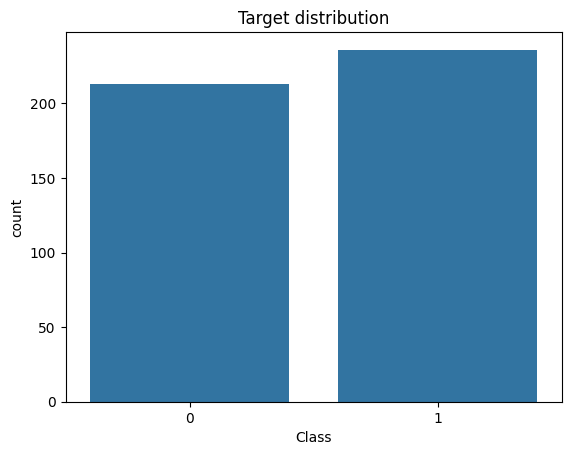

In [25]:
sns.countplot(x='Class', data = df)
plt.title("Target distribution")
plt.show()

In [26]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True)

,proportion
Class,
1,0.525612
0,0.474388


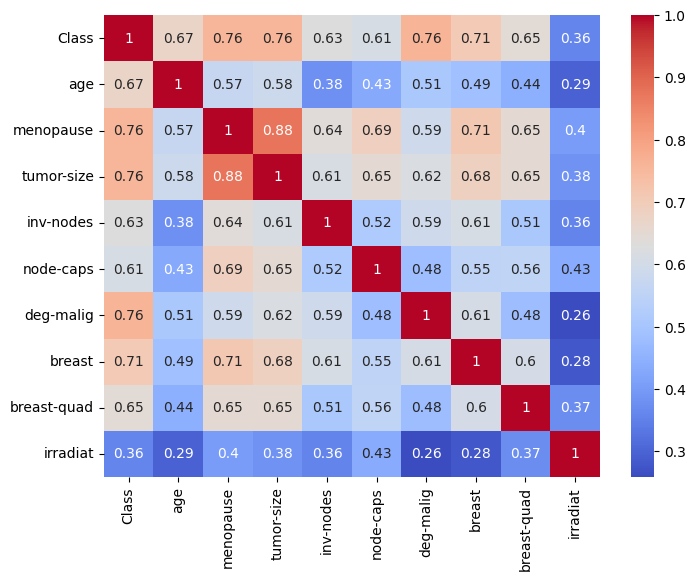

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

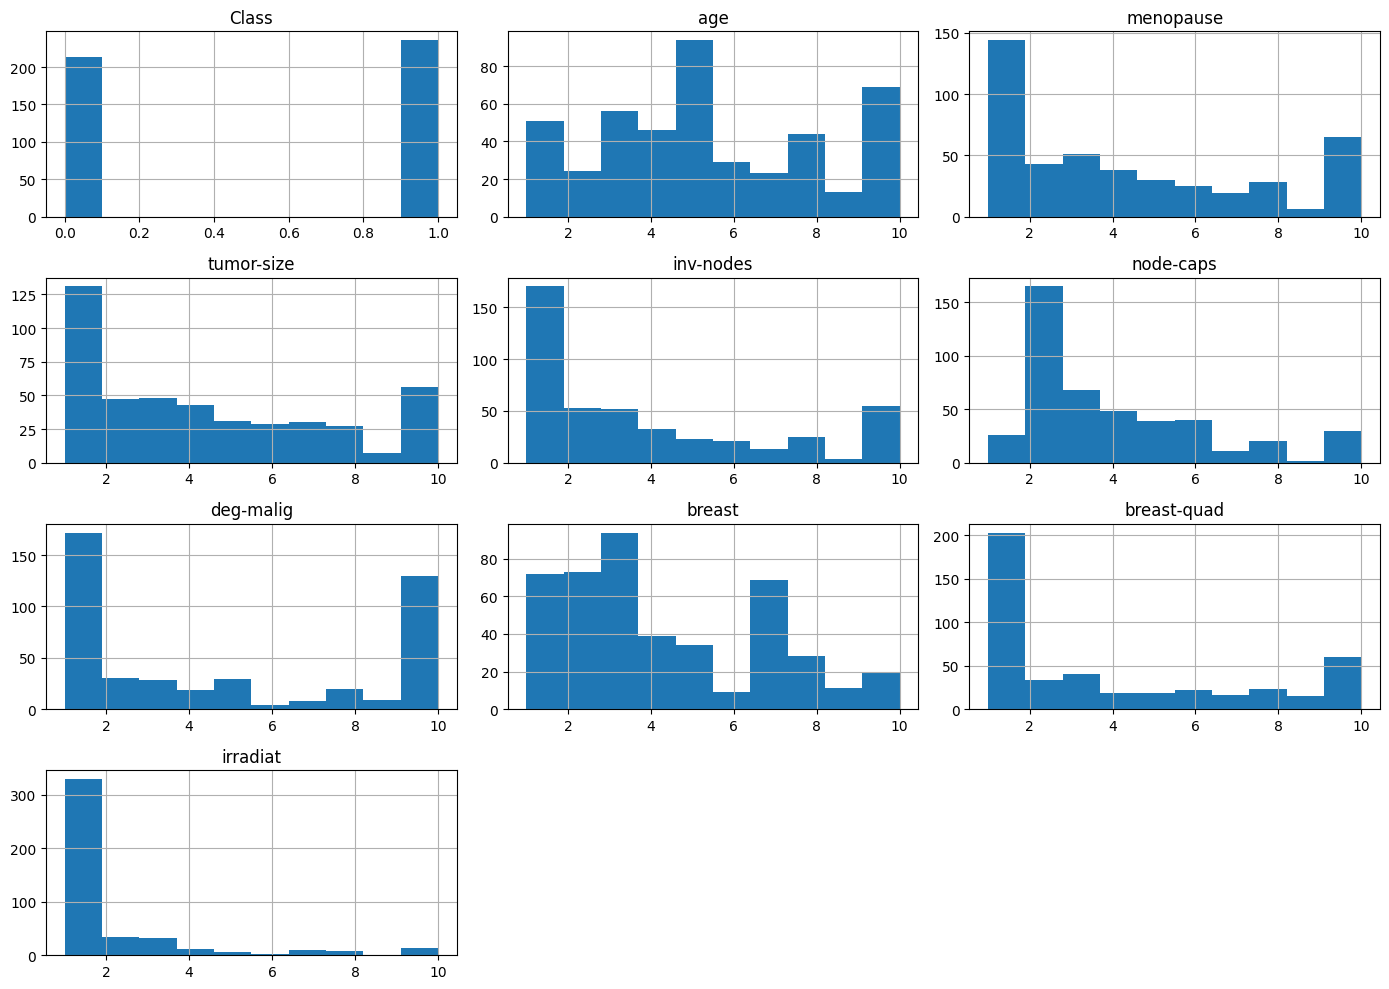

In [32]:
df.hist(figsize=(14, 10))

plt.tight_layout()
plt.show()

In [33]:
X = df.drop(['Class'], axis=1)
y = df['Class']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [49]:
# Logistic Regression

model = LogisticRegression()
model.fit(X_train_scaler, y_train)

LogisticRegression()

In [50]:
y_pred = model.predict(X_test_scaler)
y_prob = model.predict_proba(X_test_scaler)[:, 1]

print(y_pred)
print(y_prob)

[1 0 1 1 0 1 1 0 1 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 1 0 1 0 1 1
 0 0 1 0 0 1 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 0 1
 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0]
[0.98232657 0.03867555 0.7365359  0.89410546 0.02780587 0.98732026
 0.94002213 0.0230761  0.9713078  0.04082726 0.97185868 0.06135225
 0.01412676 0.99695688 0.96600065 0.98612188 0.05361671 0.00683204
 0.00369711 0.0291915  0.08325586 0.00989368 0.27778394 0.00361993
 0.00278024 0.99927046 0.99952042 0.99390747 0.99989588 0.99935476
 0.02640868 0.96299246 0.01410952 0.9984284  0.03243796 0.99905116
 0.93948036 0.00968541 0.02033191 0.98604882 0.07842408 0.03534899
 0.99945712 0.99436988 0.99815324 0.09773871 0.93818409 0.98384813
 0.37334402 0.01457979 0.99457391 0.01641285 0.99926442 0.99948471
 0.00922016 0.99986285 0.013577   0.9994671  0.02089705 0.89509782
 0.00907296 0.99549975 0.73442197 0.9930832  0.99648115 0.99998781
 0.99028448 0.99734898 0.02993877 0.06372474 0.98498771 0.98399871
 0.04485935 

In [52]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9777777777777777


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.96      1.00      0.98        47

    accuracy                           0.98        90
   macro avg       0.98      0.98      0.98        90
weighted avg       0.98      0.98      0.98        90



## Confusion Matrix

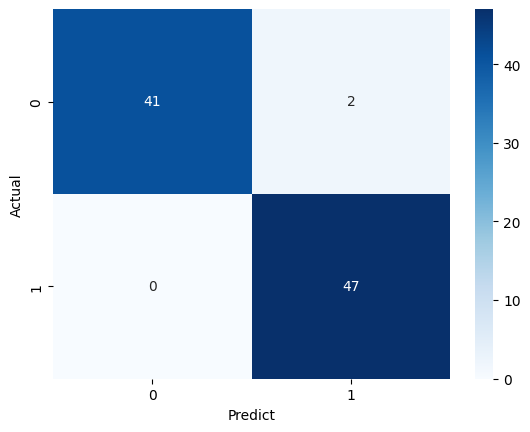

In [54]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues")
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.show()

## DecisionTreeClassifier


In [58]:
model_dtc = DecisionTreeClassifier()
model_dtc.fit(X_train_scaler, y_train)

DecisionTreeClassifier()

In [59]:
y_pred_dtc = model_dtc.predict(X_test_scaler)
y_pred_dtc

array([1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0])

In [60]:
print(classification_report(y_test, y_pred_dtc))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        43
           1       0.93      0.91      0.92        47

    accuracy                           0.92        90
   macro avg       0.92      0.92      0.92        90
weighted avg       0.92      0.92      0.92        90

